In [1]:
# Import necessary libraries (if not already imported)
import pandas as pd
import gdown

# Google Drive file ID extracted from the new URL
new_file_id = '1JEV3UWouADht3_jCfHfwerLJ3u_4G6A2'

# Output filename for the newly downloaded dataset
new_output_filename = 'precast_truncated_data_new.csv'

# Download the file from Google Drive
gdown.download(id=new_file_id, output=new_output_filename, quiet=False)

# Load the CSV file into a pandas DataFrame named df_precast_truncated
df_precast_truncated = pd.read_csv(new_output_filename)



Downloading...
From: https://drive.google.com/uc?id=1JEV3UWouADht3_jCfHfwerLJ3u_4G6A2
To: /content/precast_truncated_data_new.csv
100%|██████████| 3.11M/3.11M [00:00<00:00, 36.5MB/s]


In [2]:
# Display the first 5 rows of the new DataFrame to confirm
print(f"Successfully downloaded and loaded '{new_output_filename}' into df_precast_truncated.")
display(df_precast_truncated.head())

Successfully downloaded and loaded 'precast_truncated_data_new.csv' into df_precast_truncated.


,Cement_type,Cement_content_kgm3,Water_cement_ratio,Flyash_percent,Target_grade_MPa,Curing_method,Steam_temp_C,Steam_duration_hr,Curing_start_delay_hr,Chamber_humidity_pct,...,Reset_time_min,Equipment_downtime_min,Early_strength_requirement_MPa,Initial_strength_12hr_MPa,Maturity_index,Energy_cost_rate_INR_per_kWh,Time_to_reach_demould_strength_hr,Cycle_time_hr,Total_cycle_cost_INR,Cost_per_element_INR
0,OPC,317.885987,0.519181,0.000000,35,hot_air,40.804019,0.000000,3.262302,20.799732,...,27.786001,65.023501,14.050675,34.263590,178.621326,NaN,4.000000,10.236851,10715.891884,10715.891884
1,PPC,448.950069,0.407100,17.883239,60,hot_air,29.675710,0.000000,1.142725,80.314101,...,36.892672,7.364056,26.500506,64.886517,108.656742,NaN,4.000000,9.122386,11116.549990,11116.549990
2,PSC,455.062583,0.384208,0.000000,60,steam,60.919612,6.933528,3.299453,97.425196,...,19.407960,6.121557,27.191834,67.437687,179.514766,NaN,5.271681,12.061947,11522.319162,11522.319162
3,OPC,385.163632,0.441217,0.000000,50,steam,68.779597,11.990496,3.133763,92.589322,...,25.440046,8.175773,22.263120,54.298224,250.036008,NaN,8.378536,15.202162,15314.218715,15314.218715
4,PPC,335.625342,0.518995,34.578905,40,steam,70.959092,9.272804,1.737398,96.674101,...,15.568078,9.815283,18.896595,44.489453,273.363518,NaN,4.964671,8.169465,12138.529454,12138.529454


In [3]:
# --- 1. Imports & Configuration ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)
print("✅ Libraries imported and 'models/' directory verified.")

✅ Libraries imported and 'models/' directory verified.


In [4]:
# --- 2. Data Preparation & Feature Splitting ---

# Define targets
targets = ['Time_to_reach_demould_strength_hr', 'Cycle_time_hr', 'Total_cycle_cost_INR']

# Identify all potential feature columns first
all_cols = df_precast_truncated.columns.tolist()
exclude_cols = targets + ['Cost_per_element_INR'] # Known leakage
initial_feature_cols = [col for col in all_cols if col not in exclude_cols]

# Separate numerical and categorical columns early for analysis
numerical_cols = df_precast_truncated[initial_feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_precast_truncated[initial_feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

# --- 2a. Clean Constant Columns (Fixes Scaler Warnings) ---
constant_cols = [col for col in numerical_cols if df_precast_truncated[col].std() == 0]
if constant_cols:
    print(f"⚠️ Dropping constant columns: {constant_cols}")
    numerical_cols = [c for c in numerical_cols if c not in constant_cols]
else:
    print("✅ No constant numerical columns found.")

# --- 2b. Check for Leakage (High Correlation) ---
print("\nChecking for leakage (Correlation > 0.95 with any target)...")
leakage_candidates = []
correlation_matrix = df_precast_truncated[numerical_cols + targets].corr()

for target in targets:
    high_corr = correlation_matrix[target][abs(correlation_matrix[target]) > 0.95].index.tolist()
    # Remove the target itself
    high_corr = [c for c in high_corr if c not in targets]
    if high_corr:
        print(f"   ⚠️ Potential Leakage for '{target}': {high_corr}")
        leakage_candidates.extend(high_corr)

if not leakage_candidates:
    print("✅ No obvious leakage found (correlation < 0.95).")
else:
    # Optional: Automatically remove leakage candidates?
    # For now, we will print them. If you want to drop them, uncomment:
    # numerical_cols = [c for c in numerical_cols if c not in leakage_candidates]
    print(f"ℹ️ Review the above list. If these look like derived features, remove them.")

# Final Feature List
feature_cols = numerical_cols + categorical_cols

print(f"\n✅ Feature Selection Complete:")
print(f"   - Total Features: {len(feature_cols)}")
print(f"   - Numerical: {len(numerical_cols)} ({numerical_cols})")
print(f"   - Categorical: {len(categorical_cols)} ({categorical_cols})")
print(f"   - Targets: {targets}")

# Split input (X) and output (Y)
X = df_precast_truncated[feature_cols]
Y = df_precast_truncated[targets]

# Train/Test Split (80/20)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, shuffle=True)
print(f"✅ Data Split Complete: Train Shape {X_train.shape}, Test Shape {X_test.shape}")

✅ No constant numerical columns found.

Checking for leakage (Correlation > 0.95 with any target)...
✅ No obvious leakage found (correlation < 0.95).

✅ Feature Selection Complete:
   - Total Features: 24
   - Numerical: 21 (['Cement_content_kgm3', 'Water_cement_ratio', 'Flyash_percent', 'Target_grade_MPa', 'Steam_temp_C', 'Steam_duration_hr', 'Curing_start_delay_hr', 'Chamber_humidity_pct', 'Ambient_temp_C', 'Relative_humidity_pct', 'Wind_speed_mps', 'Daytime_hours', 'Automation_level', 'No_of_moulds', 'Cleaning_time_min', 'Reset_time_min', 'Equipment_downtime_min', 'Early_strength_requirement_MPa', 'Initial_strength_12hr_MPa', 'Maturity_index', 'Energy_cost_rate_INR_per_kWh'])
   - Categorical: 3 (['Cement_type', 'Curing_method', 'Season'])
   - Targets: ['Time_to_reach_demould_strength_hr', 'Cycle_time_hr', 'Total_cycle_cost_INR']
✅ Data Split Complete: Train Shape (6400, 24), Test Shape (1600, 24)


In [5]:
# --- 3. Preprocessing Setup ---

# 1. Pipeline Definition:
# - Numerical: Impute NaNs -> Standard Scaling (Handles missing/outliers)
# - Categorical: One-Hot Encoding (ignore unknown)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    verbose_feature_names_out=False
)

# 2. Fit the pipeline on the TRAIN set only to prevent leakage
# We keep this as a separate object so we can use it interchangeably
preprocessor.fit(X_train)

# 3. Transform X_train so we have processed features
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Verify Output Shape
print(f"✅ Preprocessing Setup Complete.")
print(f"   Original Features: {X_train.shape[1]}")
print(f"   Processed Features: {X_train_processed.shape[1]}")

# Save the fitted pipeline
joblib.dump(preprocessor, 'models/precast_pipeline.pkl')
print("✅ Pipeline Saved: models/precast_pipeline.pkl")

✅ Preprocessing Setup Complete.
   Original Features: 24
   Processed Features: 30
✅ Pipeline Saved: models/precast_pipeline.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Energy_cost_rate_INR_per_kWh']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Energy_cost_rate_INR_per_kWh']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Energy_cost_rate_INR_per_kWh']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [6]:
# --- 4. Model Training (3 Independent Models) ---

# We train 3 separate XGBoost Regressors for the 3 target variables.
# This prevents one overly dominating target (like Total Cost) from influencing others via multi-output loss functions.

# Dictionary for model storage
trained_models = {}

# Target Columns for convenience
target_names = {
    'Time_to_demould': 'Time_to_reach_demould_strength_hr',
    'Cycle_time': 'Cycle_time_hr',
    'Total_cost': 'Total_cycle_cost_INR'
}

print("✅ Model Training Started...\n")

for short_name, col_name in target_names.items():
    print(f"   Training {short_name} Model...")

    # Init Model
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

    # Fit Model
    model.fit(X_train_processed, Y_train[col_name])

    # Store
    trained_models[short_name] = model

    # Basic Score (Train R2)
    train_score = model.score(X_train_processed, Y_train[col_name])
    print(f"      -> Train R2: {train_score:.4f}")

# Save the models
for name, model in trained_models.items():
    joblib.dump(model, f'models/model_{name}.pkl')

print("\n✅ All Models Trained and Saved to 'models/' directory.")

✅ Model Training Started...

   Training Time_to_demould Model...
      -> Train R2: 0.9965
   Training Cycle_time Model...
      -> Train R2: 0.9931
   Training Total_cost Model...
      -> Train R2: 0.9725

✅ All Models Trained and Saved to 'models/' directory.



Model: Time_to_demould (Time_to_reach_demould_strength_hr)
--------------------------------------------------
  MAE:  0.4956
  RMSE: 0.7516
  R2:   0.9882

Model: Cycle_time (Cycle_time_hr)
--------------------------------------------------
  MAE:  0.7999
  RMSE: 1.0430
  R2:   0.9797

Model: Total_cost (Total_cycle_cost_INR)
--------------------------------------------------
  MAE:  629.4250
  RMSE: 919.0598
  R2:   0.9204


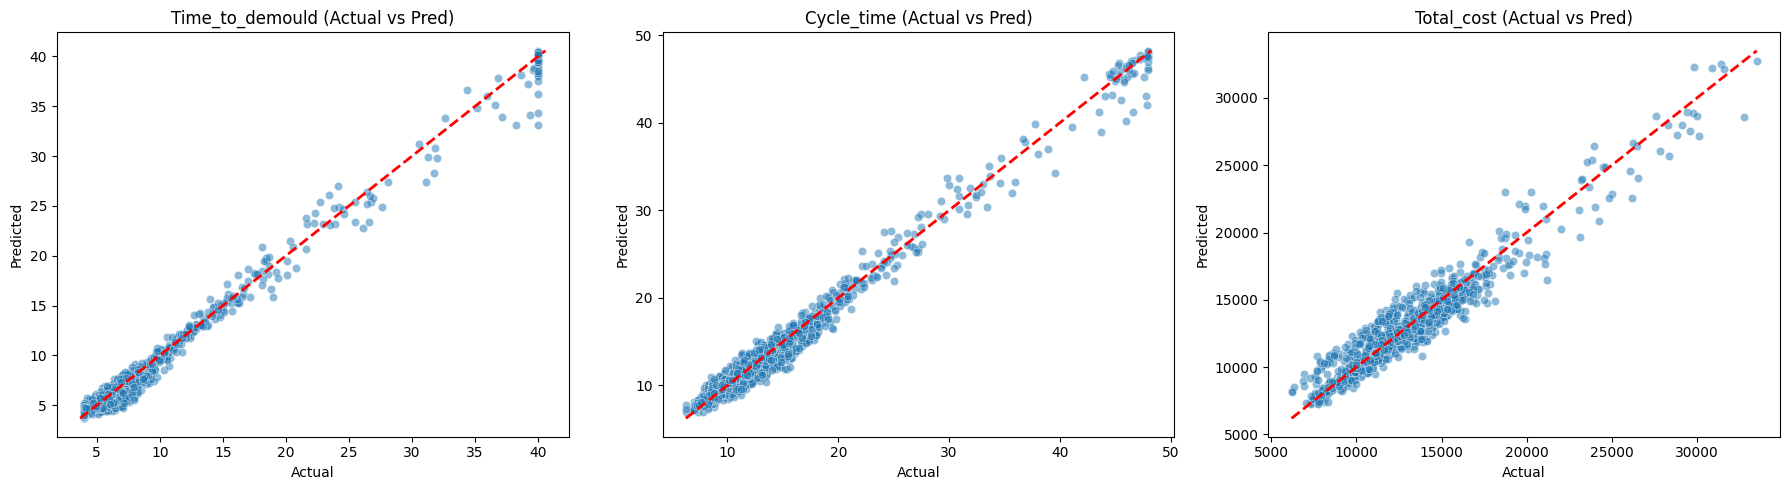

In [7]:
# --- 5. Model Evaluation ---

# Create simple storage for evaluation results
results = []

# Loop over each trained model
for short_name, target_col in target_names.items():

    # Get model and predictions
    model = trained_models[short_name]
    y_true = Y_test[target_col]
    y_pred = model.predict(X_test_processed)

    # Calculate Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    # Print Summary
    print(f"\nModel: {short_name} ({target_col})")
    print(f"--------------------------------------------------")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2:   {r2:.4f}")

    # Store for plotting later if needed
    results.append({
        'Target': short_name,
        'Y_True': y_true,
        'Y_Pred': y_pred
    })

# Visualize Function
def plot_actual_vs_predicted(results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, res in enumerate(results):
        ax = axes[i]
        sns.scatterplot(x=res['Y_True'], y=res['Y_Pred'], ax=ax, alpha=0.5)

        # Perfect prediction line
        min_val = min(res['Y_True'].min(), res['Y_Pred'].min())
        max_val = max(res['Y_True'].max(), res['Y_Pred'].max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

        ax.set_title(f"{res['Target']} (Actual vs Pred)")
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")

    plt.tight_layout()
    plt.show()

# Run Visualization
plot_actual_vs_predicted(results)

In [8]:
# --- 6. Artifact Preservation (Pipelines, Columns, Models) ---

# Make a 'meta' dict with all relevant feature information
meta_data = {
    'features': feature_cols,
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'targets': targets,
    'target_names_map': target_names, # {short name: full col name}
}

# Save metadata to JSON
with open('models/precast_meta.json', 'w') as f:
    json.dump(meta_data, f, indent=4)

print("✅ Metadata Saved: 'models/precast_meta.json'")
print("✅ Models Saved: 'models/model_*.pkl'")
print("✅ Pipeline Saved: 'models/precast_pipeline.pkl'")

# Final confirmation check
print(f"Artifacts ready strictly for Phase-2 Optimization.")

✅ Metadata Saved: 'models/precast_meta.json'
✅ Models Saved: 'models/model_*.pkl'
✅ Pipeline Saved: 'models/precast_pipeline.pkl'
Artifacts ready strictly for Phase-2 Optimization.


In [9]:
# --- 7. Evaluate Function (Canonical & Batch) ---

# This function is the BRIDGE to Phase 2.
# It MUST:
#   1. Accept raw dictionary inputs (user selections or optimizer values)
#   2. Preprocess them using the SAVED pipeline (consistent scaling)
#   3. Predict all 3 outcomes at once.

def evaluate(candidate, explain=False):
    """
    Evaluates a single candidate configuration (dict).
    Returns a dictionary of predictions {demould_time, cycle_time, cost}.
    """
    # 1. Convert dict -> DataFrame
    # Ensure all required cols exist
    df_candidate = pd.DataFrame([candidate])

    # 2. Add missing cols with NaN or default if needed (though usually strictly checked)
    # For now assume candidate has all 'feature_cols' keys

    # 3. Preprocess
    X_processed = preprocessor.transform(df_candidate)

    # 4. Predict
    t_demould = trained_models['Time_to_demould'].predict(X_processed)[0]
    cycle_time = trained_models['Cycle_time'].predict(X_processed)[0]
    cost = trained_models['Total_cost'].predict(X_processed)[0]

    result = {
        'Time_to_demould': float(t_demould),
        'Cycle_time': float(cycle_time),
        'Total_cost': float(cost)
    }

    if explain:
        result['raw_input'] = candidate

    return result


def batch_evaluate(candidates_list):
    """
    Vectorized evaluation for lists of candidates (much faster for Phase 2/3).
    input: List of dicts
    output: DataFrame of predictions
    """
    if not candidates_list:
        return pd.DataFrame()

    df_batch = pd.DataFrame(candidates_list)

    # Preprocess batch
    X_batch_proc = preprocessor.transform(df_batch)

    # Predict batch
    t_demould_preds = trained_models['Time_to_demould'].predict(X_batch_proc)
    cycle_time_preds = trained_models['Cycle_time'].predict(X_batch_proc)
    cost_preds = trained_models['Total_cost'].predict(X_batch_proc)

    return pd.DataFrame({
        'Time_to_demould': t_demould_preds,
        'Cycle_time': cycle_time_preds,
        'Total_cost': cost_preds
    })

# --- VALIDATION TEST ---
# Test evaluate() with the first row of our test set to verify it works End-to-End
test_row = X_test.iloc[0].to_dict()
print("Running Single Test Evaluation:")
print(f"Test Input (First 3 keys): {dict(list(test_row.items())[:3])} ...")

single_pred = evaluate(test_row)
print("Single Prediction Result:", single_pred)

# Test batch_evaluate() with the first 5 rows
print("\nRunning Batch Test Evaluation (5 rows):")
batch_preds = batch_evaluate(X_test.iloc[:5].to_dict(orient='records'))
print(batch_preds)

print("\n✅ PHASE 1 COMPLETE: Training, Saving, and Evaluate Function Ready.")

Running Single Test Evaluation:
Test Input (First 3 keys): {'Cement_content_kgm3': 282.22634716354503, 'Water_cement_ratio': 0.5447135968211503, 'Flyash_percent': 0.0} ...
Single Prediction Result: {'Time_to_demould': 4.023231506347656, 'Cycle_time': 7.692406177520752, 'Total_cost': 10333.7177734375}

Running Batch Test Evaluation (5 rows):
   Time_to_demould  Cycle_time    Total_cost
0         4.023232    7.692406  10333.717773
1         4.115304    9.489480  13753.813477
2         6.540197   12.358388  12035.155273
3         5.769013   13.042117  12083.316406
4         5.453956   13.494648  16255.267578

✅ PHASE 1 COMPLETE: Training, Saving, and Evaluate Function Ready.


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Energy_cost_rate_INR_per_kWh']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Energy_cost_rate_INR_per_kWh']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
